In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import scipy
from scipy.integrate import solve_ivp
from IPython.display import HTML

We need to add some sort of self-centering technique: given masses and positions, we need to re-center the mass so that the center of mass is zero

In [2]:
dimensions = 2 # Don't touch this for now

# Initial conditions: feel free to edit these
masses = np.array([1, 2, 1], dtype=np.float64)
initial_positions = np.array([[1, 0], [-1, 0], [1, 1]], dtype=np.float64)
initial_velocities = np.array([[0, -1], [0, 1], [1, -1]], dtype=np.float64)

# Okay don't touch anymore
n = len(masses)
initial_positions = initial_positions.ravel()
initial_momenta = np.array([initial_velocities[i] * masses[i] for i in range(n)]).ravel()
# Someday we'll need J... I just don't know enough math to use it yet
# J = np.block([[np.zeros((n, n)), np.eye(n)], [-1 * np.eye(n), np.zeros((n, n))]])

z = np.concatenate([initial_positions, initial_momenta], axis=0)


In [3]:
def ode_approximator(t, z, masses, dimensions):
  n = len(masses)
  positions = z[:n * dimensions]
  velocities = z[n * dimensions:]

  def vectorizor(velocities):
    return [np.array(velocities[i*n:i*n + n]) for i in range(int(len(velocities) / n))]

  def acceleration_calculator():
    # G = 6.67408e-11
    G = 3
    # Reshape positions to (n, dimensions) for easier math
    pos = np.reshape(positions, (n, dimensions))
    accel = np.zeros((n, dimensions))
    epsilon = 1e-9  # Softening factor to prevent division by zero

    for i in range(n):
        for j in range(n):
            if i != j:
                diff = pos[j] - pos[i]
                # Use np.linalg.norm for the true distance
                dist = np.linalg.norm(diff)
                accel[i] += G * masses[j] * diff / (dist**3 + epsilon)

    return accel.ravel()

  change_in_positions = velocities
  change_in_velocities = acceleration_calculator()
  return np.nan_to_num(np.concatenate([change_in_positions, change_in_velocities], axis=0))

def centering(z, masses):
  n = len(masses)
  positions = z[:n * dimensions]
  velocities = z[n * dimensions:]
  x_pos = positions[0::dimensions]
  y_pos = positions[1::dimensions]
  x_vel = velocities[0::dimensions]
  y_vel = velocities[1::dimensions]
  # Centering (which might be bad)
  x_pos -= np.mean(x_pos)
  y_pos -= np.mean(y_pos)
  # x_vel -= np.mean(x_vel) # Not working for some reason
  # y_vel -= np.mean(y_vel)
  return np.array([x_pos, y_pos, x_vel, y_vel]).ravel()

In [4]:
t_eval = np.linspace(0, 10, 10000)
centered_z = centering(z, masses)

sol = solve_ivp(
    fun=ode_approximator,
    t_span=(t_eval[0], t_eval[-1]),
    y0=centered_z,
    # y0=z,
    args=(masses, dimensions),              # 'masses' and 'dimensions' go here
    t_eval = t_eval,
    method='RK45'
)

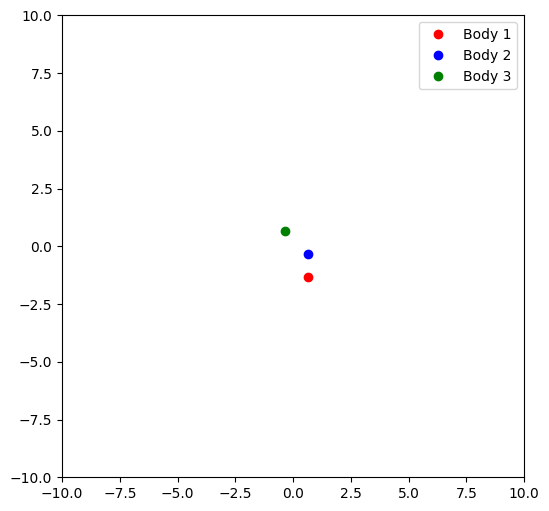

In [5]:
x1, y1 = sol.y[0, :], sol.y[1, :]
x2, y2 = sol.y[2, :], sol.y[3, :]
x3, y3 = sol.y[4, :], sol.y[5, :]
fig, ax = plt.subplots(figsize=(6, 6))

# Set the limits based on your expected motion
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')

# Initialize the drawing objects (empty points)
body1, = ax.plot([], [], 'ro', label='Body 1') # Red Circle
body2, = ax.plot([], [], 'bo', label='Body 2') # Blue Circle
body3, = ax.plot([], [], 'go', label='Body 3') # Blue Circle
ax.legend()

def update(frame):
    # Update the data for each point at the current 'frame' index
    body1.set_data([x1[frame]], [y1[frame]])
    body2.set_data([x2[frame]], [y2[frame]])
    body3.set_data([x3[frame]], [y3[frame]])
    return body1, body2

# Create the animation
ani = FuncAnimation(
    fig, update, frames=len(sol.t), interval=20, blit=True
)

In [6]:
anim_video = ani.to_html5_video()
HTML(anim_video)